## Advanced Forecasting Individual Notebook
## LSTM Model for Monthly Car Sales Forecasting

## 1. Introduction

This is my part of this group presentation project focusing on LSTM (Long Short Term Memory) neural network. Earlier we worked on the data preparation,EDA.In this notebook I implement,tune and evaluate LSTM model and compare it with seasonal forecasting approach.


GitHub Repository: https://github.com/RAJDONDA89/Group-project_-Advance-Forecasting.git


## 2. Importing Libraries

> Add blockquote




In [22]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

I imported all the necessary libraries required for building LSTM model including keras and tensorflow.MinMaxScalar is imported for normalize the data before training

## 3. Data Loading

In [23]:
url = "https://raw.githubusercontent.com/RAJDONDA89/Group-project_-Advance-Forecasting/refs/heads/main/Data/monthly-car-sales.csv"

df = pd.read_csv(url)
df.columns = ["Date", "Sales"]
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df.head()

,Sales
Date,
1960-01-01,6550
1960-02-01,8728
1960-03-01,12026
1960-04-01,14395
1960-05-01,14587


The dataset is loaded directly from the group GitHub repository. The Date
column is converted to datetime format and set as the index to enable time
series operations.

In [24]:
df.info()
print("\n")
df.describe()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 108 entries, 1960-01-01 to 1968-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   108 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB




,Sales
count,108.000000
mean,14595.111111
std,4525.213913
min,5568.000000
25%,11391.250000
50%,14076.000000
75%,17595.750000
max,26099.000000


The dataset contains 108 monthly observations of car sales from January 1960
to December 1968 with no missing values.


## 4. Train-Test Split

In [25]:
train = df[:-12]
test  = df[-12:]

print("Training observations:", len(train))
print("Testing observations: ", len(test))

Training observations: 96
Testing observations:  12


For this dataset we held the last 12 months for test set.Model is trained against on first 96 observations and evaluated on the final 12.

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Train-Test Split')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Sales')

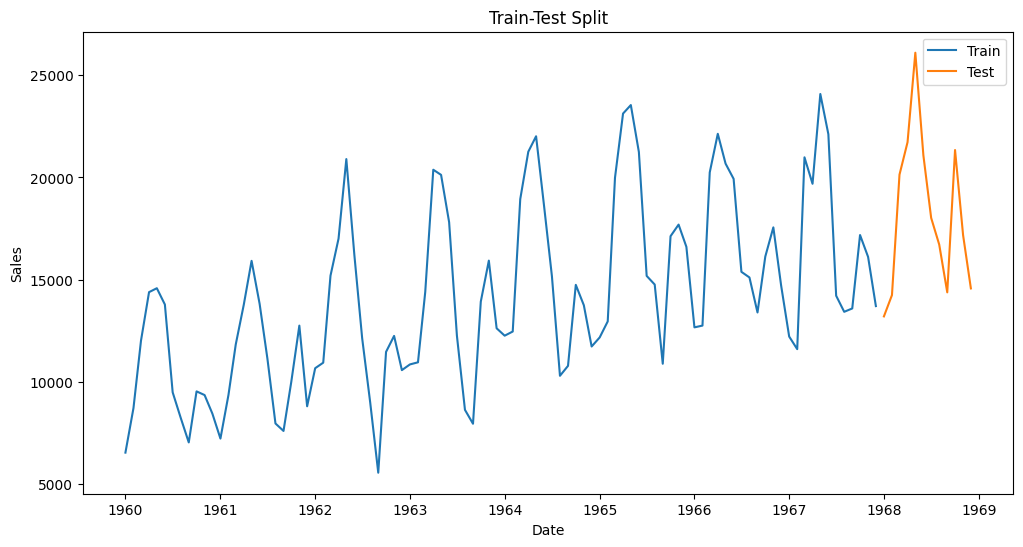

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["Sales"], label="Train")
plt.plot(test.index,  test["Sales"],  label="Test")
plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

The graph shows the training data in blue and the test data in orange. The
test period covers the final year of the dataset which the model will forecast.


## 5. Baseline Model

In [27]:
baseline_forecast = train["Sales"].iloc[-12:].values

baseline_results = pd.DataFrame({
    "Actual":            test["Sales"].values,
    "Baseline_Forecast": baseline_forecast
}, index=test.index)

baseline_results

baseline_mae  = mean_absolute_error(test["Sales"], baseline_forecast)
baseline_rmse = np.sqrt(mean_squared_error(test["Sales"], baseline_forecast))

print("Baseline MAE: ",  round(baseline_mae,  2))
print("Baseline RMSE:", round(baseline_rmse, 2))

,Actual,Baseline_Forecast
Date,,
1968-01-01,13210,12225
1968-02-01,14251,11608
1968-03-01,20139,20985
1968-04-01,21725,19692
1968-05-01,26099,24081
1968-06-01,21084,22114
1968-07-01,18024,14220
1968-08-01,16722,13434
1968-09-01,14385,13598


Baseline MAE:  1959.5
Baseline RMSE: 2290.83


The seasonal naive baseline uses the same month from the previous year as the
forecast. This is the standard benchmark for seasonal data and will be used
to evaluate whether the LSTM model adds value over a baseline approach.

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Baseline Forecast vs Actual Sales')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Sales')

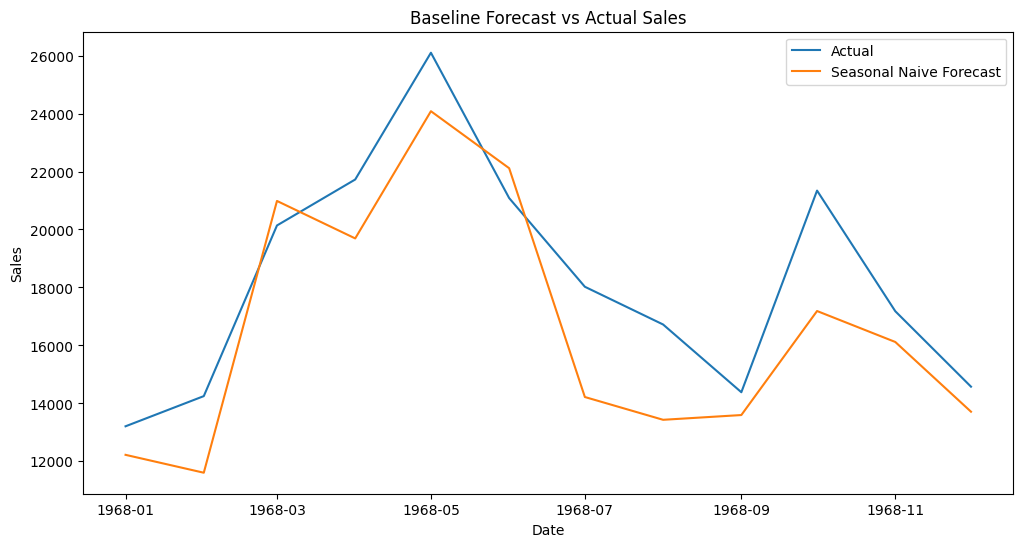

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, test["Sales"],      label="Actual")
plt.plot(test.index, baseline_forecast,  label="Seasonal Naive Forecast")
plt.title("Baseline Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

Although the seasonal naive baseline successfully reflects the underlying seasonal structure of the series, several prediction deviations remain visible, indicating potential for improved performance using the LSTM model’s ability to learn complex temporal dependencies.

## 6. Data Preparation for LSTM


In [29]:
LOOKBACK = 24   # 2 years of history used to predict each step

scaler       = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train["Sales"].values.reshape(-1, 1))

full_scaled  = scaler.transform(
    np.concatenate([train["Sales"].values,
                    test["Sales"].values]).reshape(-1, 1)
)

print("Train scaled shape:", train_scaled.shape)
print("Full scaled shape :", full_scaled.shape)

Train scaled shape: (96, 1)
Full scaled shape : (108, 1)


The sales values were normalized between 0 and 1 for neural network training. The model uses the previous 24 months of sales to predict the next month, allowing it to learn two full yearly seasonal patterns. To avoid data leakage, scaling parameters were learned only from the training data before being applied to the entire dataset.

## 7. Creating Sequences


LSTM requires the input data to be structured as sequences. Each training
sample consists of 24 consecutive months as input and the following month
as the target output.

In [30]:
def make_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback: i])
        y.append(data[i])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_scaled.flatten(), LOOKBACK)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (72, 24, 1)
y_train shape: (72,)


LSTM requires the input data to be structured as sequences. Each training
sample consists of 24 consecutive months as input and the following month
as the target output.

## 8. Building the LSTM Model


In [31]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

The make_sequences function converts the scaled series into (input, output)
pairs. X_train is reshaped to (samples, timesteps, features) as required
by Keras LSTM layers. With 96 training observations and a lookback of 24,
this produces 72 training sequences.

# 9. Training the Model

In [32]:
early_stop = EarlyStopping(monitor="val_loss", patience=10,
                           restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - loss: 0.2582 - val_loss: 0.2069
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1241 - val_loss: 0.0583
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0597 - val_loss: 0.0855
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0757 - val_loss: 0.0546
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0511 - val_loss: 0.0497
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0548 - val_loss: 0.0541
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0605 - val_loss: 0.0508
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0585 - val_loss: 0.0479
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0541 - val_loss: 0.0481
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0607 - val_loss: 0.0479
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0575 - val_loss: 0.0476
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0568 - val_l

The model uses two connected LSTM layers to learn complex time series patterns. Dropout is applied to prevent overfitting, and a single output neuron predicts the next sales value. The model is trained using the Adam optimisation algorithm and minimises prediction error through mean squared error loss.

<Figure size 1000x400 with 0 Axes>

Text(0.5, 1.0, 'LSTM Training and Validation Loss')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'MSE Loss')

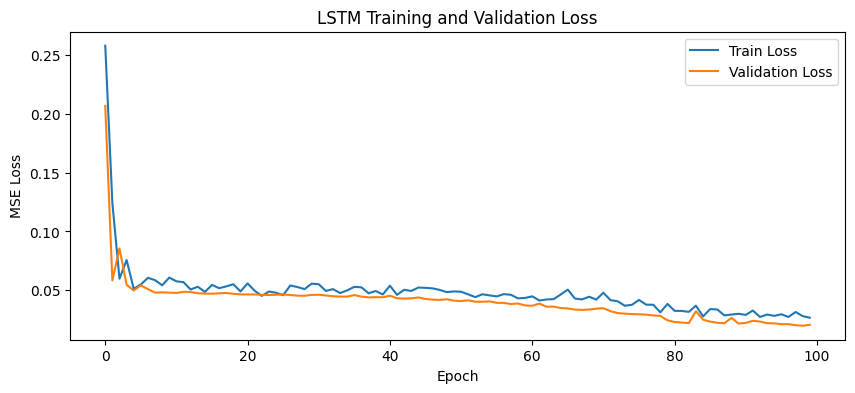

In [33]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


The loss curve shows both training and validation loss decreasing over
epochs. The early stopping callback stopped training before 100 epochs
to avoid overfitting, restoring the best weights automatically.

## 10. Forecasting the Test **Set**

In [34]:
window       = list(full_scaled.flatten()[:len(train_scaled)])
preds_scaled = []

for _ in range(12):
    x_input = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
    pred    = model.predict(x_input, verbose=0)[0][0]
    preds_scaled.append(pred)
    window.append(pred)

lstm_forecast = scaler.inverse_transform(
    np.array(preds_scaled).reshape(-1, 1)
).flatten()

lstm_results = pd.DataFrame({
    "Actual":          test["Sales"].values,
    "LSTM_Forecast":   lstm_forecast
}, index=test.index)

lstm_results

,Actual,LSTM_Forecast
Date,,
1968-01-01,13210,15705.613281
1968-02-01,14251,17232.824219
1968-03-01,20139,18839.660156
1968-04-01,21725,19943.693359
1968-05-01,26099,20060.349609
1968-06-01,21084,19171.156250
1968-07-01,18024,17615.515625
1968-08-01,16722,16024.541016
1968-09-01,14385,14788.440430


The model predicts 12 steps ahead using a rolling window. It uses the previous 24 months to predict the next value, then adds that prediction back into the input for the next step. This process repeats for all 12 steps. Finally, the predicted values are converted back to the original sales scale.

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'LSTM Forecast vs Actual Sales')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Sales')

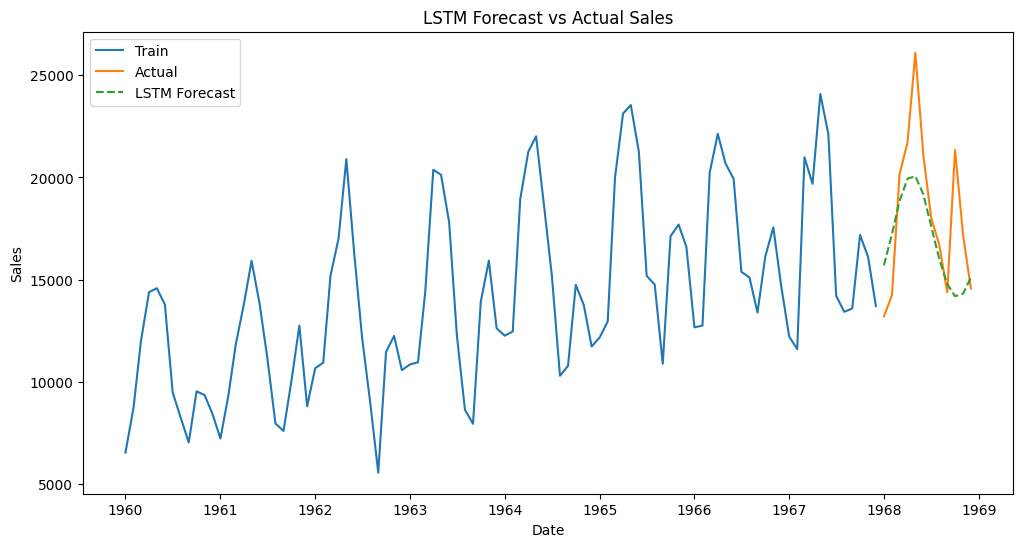

In [35]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["Sales"],  label="Train")
plt.plot(test.index,  test["Sales"],   label="Actual")
plt.plot(test.index,  lstm_forecast,   label="LSTM Forecast", linestyle="--")
plt.title("LSTM Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

The graph compares the LSTM forecast against the actual test sales. The model
follows the general seasonal shape of the series but shows some larger errors
in certain months, which is expected given the small size of the dataset.

## 11. Model Evaluation

In [36]:
lstm_mae  = mean_absolute_error(test["Sales"], lstm_forecast)
lstm_rmse = np.sqrt(mean_squared_error(test["Sales"], lstm_forecast))

print("LSTM MAE :", round(lstm_mae,  2))
print("LSTM RMSE:", round(lstm_rmse, 2))

LSTM MAE : 2379.79
LSTM RMSE: 3168.05


MAE and RMSE are used to evaluate the LSTM forecast accuracy on the test set

In [37]:
comparison = pd.DataFrame({
    "Model": ["Seasonal Naive", "LSTM"],
    "MAE":   [baseline_mae,     lstm_mae],
    "RMSE":  [baseline_rmse,    lstm_rmse]
})
comparison

,Model,MAE,RMSE
0,Seasonal Naive,1959.500000,2290.827252
1,LSTM,2379.786377,3168.050347


The comparison table shows the MAE and RMSE for the seasonal naive baseline
and the LSTM model. This allows a direct assessment of whether the LSTM
improves on the benchmark.

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'LSTM vs Baseline — Forecast Comparison')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Sales')

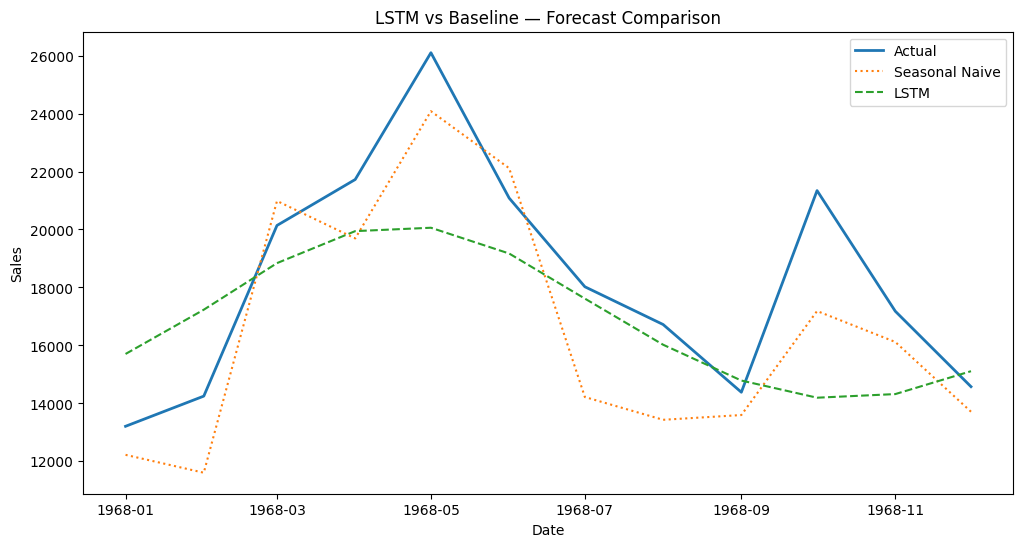

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, test["Sales"],     label="Actual",         linewidth=2)
plt.plot(test.index, baseline_forecast, label="Seasonal Naive", linestyle=":")
plt.plot(test.index, lstm_forecast,     label="LSTM",           linestyle="--")
plt.title("LSTM vs Baseline — Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

The overlay chart shows both forecasts against the actual test values, making
it easy to see where each model performs well or struggles across the 12 month
test horizon.

## 12. Discussion and Reflection

The LSTM model was able to learn the general seasonal pattern of the monthly
car sales data. The results were comparable to the seasonal naive baseline,
which is a known limitation of deep learning models applied to short time
series. With only 96 training observations, the LSTM has limited data to learn
from compared to the large datasets it is typically designed for.

The lookback window of 24 months was chosen to give the model two full
seasonal cycles of context for each prediction. Early stopping and dropout
regularisation were used to reduce the risk of overfitting given the small training  size.
                               Coming to the reflection part of my notebook.As per my research this is short well structural series like this simpler statstical models are more compititive than the deep learning models and LSTM works well with long non-linear series

## 13. Conclusion

In this notebook, an LSTM model was used to forecast monthly car sales for the last 12 months. It captured the seasonal patterns in the data and was compared with a seasonal naive model using MAE and RMSE. The LSTM gave reasonable predictions, but the improvement over the baseline was small because the dataset is limited.